# Experiment - Predict Churn or No Churn
Use ML models and tabular data to predict if a customer will churn or not.

# 0. Import Libraries and Load Data

In [33]:
# Data Analysis
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import lightgbm as lgb
import xgboost as xgb
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, learning_curve
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

In [34]:
df = pd.read_csv("../data/Telco_customer_churn.csv")

print(df.shape)
display(df)

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


# 1. Preprocess Data

In [35]:
# Select useful columns, as seen in the data analysis step
columns = ['SeniorCitizen', 'Partner', 'Dependents', 'tenure',
           'InternetService', 'OnlineSecurity', 'OnlineBackup',
           'DeviceProtection', 'TechSupport', 'StreamingTV',
           'StreamingMovies', 'Contract', 'PaperlessBilling',
           'PaymentMethod', 'MonthlyCharges', 'Churn']

df = df[columns]

# Cast Yes/No variables to binary
yes_no_columns = ['Partner', 'Dependents', 'PaperlessBilling', 'Churn']

for column in yes_no_columns:
    df[column] = df[column].map({'Yes': 1, 'No': 0}).astype(int)

print(df.info())
display(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   SeniorCitizen     7043 non-null   int64  
 1   Partner           7043 non-null   int32  
 2   Dependents        7043 non-null   int32  
 3   tenure            7043 non-null   int64  
 4   InternetService   7043 non-null   object 
 5   OnlineSecurity    7043 non-null   object 
 6   OnlineBackup      7043 non-null   object 
 7   DeviceProtection  7043 non-null   object 
 8   TechSupport       7043 non-null   object 
 9   StreamingTV       7043 non-null   object 
 10  StreamingMovies   7043 non-null   object 
 11  Contract          7043 non-null   object 
 12  PaperlessBilling  7043 non-null   int32  
 13  PaymentMethod     7043 non-null   object 
 14  MonthlyCharges    7043 non-null   float64
 15  Churn             7043 non-null   int32  
dtypes: float64(1), int32(4), int64(2), object(

,SeniorCitizen,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,0,1,0,1,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,0
1,0,0,0,34,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,0
2,0,0,0,2,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,1
3,0,0,0,45,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,0
4,0,0,0,2,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,1,1,24,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,1,Mailed check,84.80,0
7039,0,1,1,72,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,1,Credit card (automatic),103.20,0
7040,0,1,1,11,DSL,Yes,No,No,No,No,No,Month-to-month,1,Electronic check,29.60,0
7041,1,1,0,4,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Mailed check,74.40,1


# 2. Helper Functions

In [36]:
def plot_learning_curve(
    train_sizes: np.ndarray,
    train_scores: np.ndarray,
    val_scores: np.ndarray,
    title: str = "Learning Curve",
) -> None:
    """Plots a learning curve showing PR-AUC vs. training set size.
 
    Displays mean ± 1 standard deviation bands for both training and
    validation scores across cross-validation folds. The gap between
    the two curves indicates whether the model suffers from high bias
    (both curves low) or high variance (large gap between curves).
 
    Args:
        train_sizes: Array of training subset sizes used to compute scores.
        train_scores: 2D array of shape (n_sizes, n_splits) with train PR-AUC.
        val_scores: 2D array of shape (n_sizes, n_splits) with val PR-AUC.
        title: Plot title. Defaults to "Learning Curve".
    """
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)
 
    _, ax = plt.subplots(figsize=(8, 5))
 
    # Training score band
    ax.plot(train_sizes, train_mean, "o-", color="#534AB7", label="Train PR-AUC")
    ax.fill_between(
        train_sizes,
        train_mean - train_std,
        train_mean + train_std,
        alpha=0.15,
        color="#534AB7",
    )
 
    # Validation score band
    ax.plot(train_sizes, val_mean, "o-", color="#1D9E75", label="Validation PR-AUC")
    ax.fill_between(
        train_sizes,
        val_mean - val_std,
        val_mean + val_std,
        alpha=0.15,
        color="#1D9E75",
    )
 
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Training set size")
    ax.set_ylabel("PR-AUC")
    ax.legend(loc="lower right")
    ax.set_ylim(0, 1)
    sns.despine()
    plt.tight_layout()
    plt.show()

# 3. Logistic Regression

In [37]:
def train_logistic_regression_churn(
    X: pd.DataFrame,
    y: pd.Series,
    n_splits: int = 5,
    random_state: int = 42,
    **kwargs
) -> dict:
    """Trains a Logistic Regression model for churn prediction using stratified k-fold CV.
 
    Uses StratifiedKFold to preserve the churn rate across folds, StandardScaler
    for feature normalization, and class_weight='balanced' to handle class imbalance
    without resampling. Evaluates each fold on PR-AUC (primary), ROC-AUC, precision,
    recall, and F1 for both the training fold and the validation fold.
    A large and persistent gap between train and val metrics indicates overfitting;
    similar low values on both indicate underfitting (high bias).
 
    Args:
        X: Feature matrix. Must contain only numeric columns — encode categorical
            variables before calling this function.
        y: Binary target series. 1 = churned, 0 = retained.
        n_splits: Number of folds for StratifiedKFold cross-validation. Defaults to 5.
        random_state: Random seed for reproducibility. Defaults to 42.
        **kwargs: Additional keyword arguments for LogisticRegression.
 
    Returns:
        A dict with the following keys:
            - "train_metrics" (pd.DataFrame): Per-fold scores on the training fold.
            - "val_metrics" (pd.DataFrame): Per-fold scores on the validation fold.
            - "train_mean" (pd.Series): Mean of each train metric across all folds.
            - "val_mean" (pd.Series): Mean of each val metric across all folds.
            - "train_std" (pd.Series): Std of each train metric across all folds.
            - "val_std" (pd.Series): Std of each val metric across all folds.
            - "models" (list[LogisticRegression]): Fitted model from each fold.
            - "scalers" (list[StandardScaler]): Fitted scaler from each fold.
            - "feature_importance" (pd.DataFrame): Mean absolute coefficient per
              feature, sorted descending.
            - "learning_curve" (dict): Contains "train_sizes", "train_scores",
              and "val_scores" arrays used to plot the learning curve.
 
    Raises:
        ValueError: If X and y have different numbers of rows.
        ValueError: If y contains values other than 0 and 1.
 
    Example:
        >>> result = train_logistic_regression_churn(X_encoded, y, n_splits=5)
        >>> print(result["train_mean"])
        >>> print(result["val_mean"])
        >>> print(result["feature_importance"].head(10))
    """
    # ── Input validation ───────────────────────────────────────────────────────
 
    if len(X) != len(y):
        raise ValueError(
            f"X and y must have the same number of rows. "
            f"Got X={len(X)}, y={len(y)}."
        )
 
    unique_values = set(y.unique())
    if not unique_values.issubset({0, 1}):
        raise ValueError(
            f"y must contain only binary values (0 and 1). "
            f"Got: {unique_values}."
        )
 
    # ── Cross-validation setup ─────────────────────────────────────────────────
 
    # StratifiedKFold preserves the churn rate in each fold,
    # which is critical for imbalanced targets.
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
 
    # Storage for per-fold results — tracked separately for train and val
    train_fold_metrics = []
    val_fold_metrics   = []
    models  = []
    scalers = []
    coef_matrix = []
 
    # ── Training loop ──────────────────────────────────────────────────────────
 
    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), start=1):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
 
        # Scale features — logistic regression is sensitive to feature magnitude.
        # Fit scaler only on training data to avoid data leakage.
        scaler = MinMaxScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled   = scaler.transform(X_val)
 
        # Train model with balanced class weights to handle the 25/75 imbalance
        # without resampling techniques such as SMOTE.
        model = LogisticRegression(
            class_weight="balanced",
            random_state=random_state,
            **kwargs
        )
        model.fit(X_train_scaled, y_train)
 
        # ── Evaluation — train fold ────────────────────────────────────────────
 
        train_proba = model.predict_proba(X_train_scaled)[:, 1]
        train_pred  = model.predict(X_train_scaled)
 
        train_fold_metrics.append({
            "fold":      fold,
            "pr_auc":    average_precision_score(y_train, train_proba),
            "roc_auc":   roc_auc_score(y_train, train_proba),
            "precision": precision_score(y_train, train_pred, zero_division=0),
            "recall":    recall_score(y_train, train_pred, zero_division=0),
            "f1":        f1_score(y_train, train_pred, zero_division=0),
        })
 
        # ── Evaluation — validation fold ──────────────────────────────────────
 
        val_proba = model.predict_proba(X_val_scaled)[:, 1]
        val_pred  = model.predict(X_val_scaled)
 
        # PR-AUC is the primary metric for imbalanced churn datasets
        val_fold_metrics.append({
            "fold":      fold,
            "pr_auc":    average_precision_score(y_val, val_proba),
            "roc_auc":   roc_auc_score(y_val, val_proba),
            "precision": precision_score(y_val, val_pred, zero_division=0),
            "recall":    recall_score(y_val, val_pred, zero_division=0),
            "f1":        f1_score(y_val, val_pred, zero_division=0),
        })
 
        models.append(model)
        scalers.append(scaler)
 
        # Store absolute coefficients for feature importance aggregation
        coef_matrix.append(np.abs(model.coef_[0]))
 
        fold_train_df = pd.DataFrame([train_fold_metrics[-1]]).set_index("fold")
        fold_val_df = pd.DataFrame([val_fold_metrics[-1]]).set_index("fold")

        print(f"Fold {fold} metrics")
        print("Train metrics:")
        print(fold_train_df.T)
        print("Validation metrics:")
        print(fold_val_df.T)
        print()

        print(f"Confusion Matrix (Val):\n{confusion_matrix(y_val, val_pred)}\n")
 
    # ── Aggregate results ──────────────────────────────────────────────────────
 
    train_metrics_df = pd.DataFrame(train_fold_metrics).set_index("fold")
    val_metrics_df   = pd.DataFrame(val_fold_metrics).set_index("fold")
 
    train_mean = train_metrics_df.mean()
    train_std  = train_metrics_df.std()
    val_mean   = val_metrics_df.mean()
    val_std    = val_metrics_df.std()
 
    print("\n── Cross-validation summary ──────────────────────────")
    print(f"{'metric':>10} {'train mean':>12} {'train std':>10} {'val mean':>10} {'val std':>10}")
    print("-" * 56)
    for metric in val_metrics_df.columns:
        print(
            f"{metric:>10} "
            f"{train_mean[metric]:>12.4f} "
            f"{train_std[metric]:>10.4f} "
            f"{val_mean[metric]:>10.4f} "
            f"{val_std[metric]:>10.4f}"
        )
 
    # ── Feature importance ─────────────────────────────────────────────────────
 
    # Average absolute coefficient across folds as a proxy for feature importance.
    # Coefficients are comparable because features were standardized.
    mean_coefs = np.mean(coef_matrix, axis=0)
    feature_importance = (
        pd.DataFrame({
            "feature":    X.columns,
            "importance": mean_coefs,
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )
 
    # ── Learning curve ─────────────────────────────────────────────────────────
 
    # Pipeline wraps scaler + model so learning_curve applies scaling correctly
    # at each training subset, avoiding data leakage across subset sizes.
    lc_pipeline = Pipeline([
        ("scaler", MinMaxScaler()),
        ("clf", LogisticRegression(
            class_weight="balanced",
            random_state=random_state,
            **kwargs
        )),
    ])
 
    train_sizes, train_scores, val_scores = learning_curve(
        estimator=lc_pipeline,
        X=X,
        y=y,
        cv=StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state),
        scoring="average_precision",   # PR-AUC — consistent with primary metric
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1,
    )
 
    plot_learning_curve(
        train_sizes=train_sizes,
        train_scores=train_scores,
        val_scores=val_scores,
        title="Learning Curve — Logistic Regression",
    )
 
    return {
        "train_metrics":      train_metrics_df,
        "val_metrics":        val_metrics_df,
        "train_mean":         train_mean,
        "val_mean":           val_mean,
        "train_std":          train_std,
        "val_std":            val_std,
        "models":             models,
        "scalers":            scalers,
        "feature_importance": feature_importance,
        "learning_curve": {
            "train_sizes":  train_sizes,
            "train_scores": train_scores,
            "val_scores":   val_scores,
        },
    }

In [38]:
# Initialize with pandas output enabled
encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")

# Encode specific columns
encoded_data = encoder.fit_transform(df.drop(columns='Churn').select_dtypes(include="object"))

# Concatenate back with original numerical columns
df_final = pd.concat([df.drop(columns=df.select_dtypes(include="object").columns).drop(columns='Churn'), encoded_data], axis=1)
y = df["Churn"]

Fold 1 metrics
Train metrics:
fold              1
pr_auc     0.647138
roc_auc    0.842485
precision  0.516297
recall     0.794649
f1         0.625922
Validation metrics:
fold              1
pr_auc     0.649371
roc_auc    0.853596
precision  0.524390
recall     0.804813
f1         0.635021

Confusion Matrix (Val):
[[762 273]
 [ 73 301]]

Fold 2 metrics
Train metrics:
fold              2
pr_auc     0.647318
roc_auc    0.845834
precision  0.518245
recall     0.797993
f1         0.628391
Validation metrics:
fold              2
pr_auc     0.643328
roc_auc    0.841227
precision  0.513378
recall     0.820856
f1         0.631687

Confusion Matrix (Val):
[[744 291]
 [ 67 307]]

Fold 3 metrics
Train metrics:
fold              3
pr_auc     0.636481
roc_auc    0.840667
precision  0.513734
recall     0.800669
f1         0.625882
Validation metrics:
fold              3
pr_auc     0.684377
roc_auc    0.859247
precision  0.521664
recall     0.804813
f1         0.633018

Confusion Matrix (Val):
[[759 2

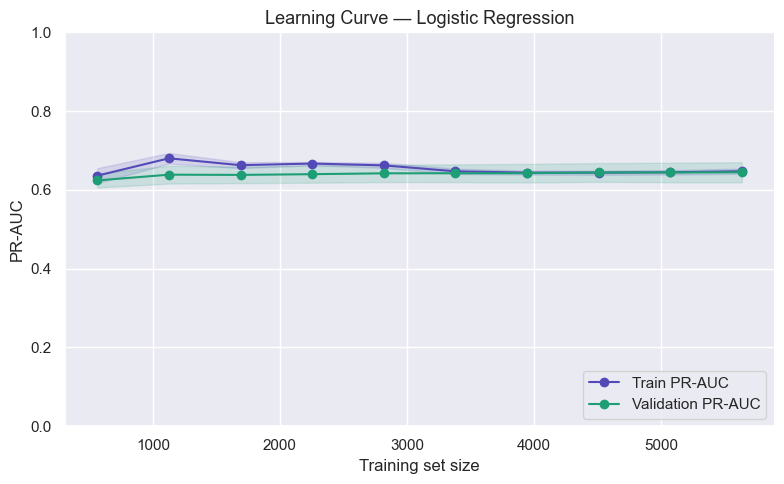

In [39]:
results_logistic_regression = train_logistic_regression_churn(pd.DataFrame(df_final), y)

In [40]:
results_logistic_regression["feature_importance"]

,feature,importance
0,tenure,2.130631
1,Contract_Two year,0.725441
2,Contract_Month-to-month,0.722802
3,MonthlyCharges,0.623021
4,InternetService_Fiber optic,0.583675
5,InternetService_DSL,0.440497
6,PaperlessBilling,0.319931
7,PaymentMethod_Electronic check,0.270617
8,StreamingMovies_Yes,0.262203
9,StreamingTV_Yes,0.251657


# 4. RandomForestClassifier

In [41]:
def train_random_forest_churn(
    X: pd.DataFrame,
    y: pd.Series,
    n_splits: int = 5,
    random_state: int = 42,
    **kwargs
    ) -> dict:
    """Trains a Random Forest model for churn prediction using stratified k-fold CV.
 
    Uses StratifiedKFold to preserve the churn rate across folds and
    class_weight='balanced' to handle class imbalance without resampling.
    Unlike Logistic Regression, Random Forest does not require feature scaling
    since it is a tree-based model that splits on feature thresholds.
    Evaluates each fold on PR-AUC (primary), ROC-AUC, precision, recall, and F1.
    Feature importance is derived from mean impurity decrease (Gini) averaged
    across all folds.
 
    Args:
        X: Feature matrix. Must contain only numeric columns — encode categorical
            variables before calling this function. No scaling required.
        y: Binary target series. 1 = churned, 0 = retained.
        n_splits: Number of folds for StratifiedKFold cross-validation. Defaults to 5.
        random_state: Random seed for reproducibility. Defaults to 42.
        **kwargs: Additional keyword arguments passed to the Random Forest classifier.
 
    Returns:
        A dict with the following keys:
            - "metrics" (pd.DataFrame): Per-fold scores for pr_auc, roc_auc,
              precision, recall, and f1.
            - "mean" (pd.Series): Mean of each metric across all folds.
            - "std" (pd.Series): Standard deviation of each metric across all folds.
            - "models" (list[RandomForestClassifier]): Fitted model from each fold.
            - "feature_importance" (pd.DataFrame): Mean Gini importance per feature
              across all folds, sorted descending.
            - "learning_curve" (dict): Contains "train_sizes", "train_scores",
              and "val_scores" arrays used to plot the learning curve.
 
    Returns:
        A dict with the following keys:
            - "metrics" (pd.DataFrame): Per-fold scores for pr_auc, roc_auc,
              precision, recall, and f1.
            - "mean" (pd.Series): Mean of each metric across all folds.
            - "std" (pd.Series): Standard deviation of each metric across all folds.
            - "models" (list[RandomForestClassifier]): Fitted model from each fold.
            - "feature_importance" (pd.DataFrame): Mean Gini importance per feature
              across all folds, sorted descending.
            - "learning_curve" (dict): Contains "train_sizes", "train_scores",
              and "val_scores" arrays used to plot the learning curve.
 
    Raises:
        ValueError: If X and y have different numbers of rows.
        ValueError: If y contains values other than 0 and 1.
 
    Example:
        >>> result = train_random_forest_churn(X_encoded, y, n_splits=5)
        >>> print(result["mean"])
        >>> print(result["feature_importance"].head(10))
    """
    # ── Input validation ───────────────────────────────────────────────────────
 
    if len(X) != len(y):
        raise ValueError(
            f"X and y must have the same number of rows. "
            f"Got X={len(X)}, y={len(y)}."
        )
 
    unique_values = set(y.unique())
    if not unique_values.issubset({0, 1}):
        raise ValueError(
            f"y must contain only binary values (0 and 1). "
            f"Got: {unique_values}."
        )
 
    # ── Cross-validation setup ─────────────────────────────────────────────────
 
    # StratifiedKFold preserves the churn rate in each fold,
    # which is critical for imbalanced targets.
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
 
    # Storage for per-fold results — tracked separately for train and val
    train_fold_metrics = []
    val_fold_metrics   = []
    models = []
    importance_matrix = []
 
    # ── Training loop ──────────────────────────────────────────────────────────
 
    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), start=1):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
 
        # No scaling needed — Random Forest splits on thresholds,
        # so feature magnitude does not affect the model.
        model = RandomForestClassifier(
            # balanced_subsample recomputes class weights for each bootstrap sample,
            # which is more robust than balanced for ensemble methods.
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=random_state,
            **kwargs
        )
        model.fit(X_train, y_train)
 
        # ── Evaluation — train fold ────────────────────────────────────────────
 
        train_proba = model.predict_proba(X_train)[:, 1]
        train_pred  = model.predict(X_train)
 
        train_fold_metrics.append({
            "fold":      fold,
            "pr_auc":    average_precision_score(y_train, train_proba),
            "roc_auc":   roc_auc_score(y_train, train_proba),
            "precision": precision_score(y_train, train_pred, zero_division=0),
            "recall":    recall_score(y_train, train_pred, zero_division=0),
            "f1":        f1_score(y_train, train_pred, zero_division=0),
        })
 
        # ── Evaluation — validation fold ──────────────────────────────────────
 
        val_proba = model.predict_proba(X_val)[:, 1]
        val_pred  = model.predict(X_val)
 
        # PR-AUC is the primary metric for imbalanced churn datasets
        val_fold_metrics.append({
            "fold":      fold,
            "pr_auc":    average_precision_score(y_val, val_proba),
            "roc_auc":   roc_auc_score(y_val, val_proba),
            "precision": precision_score(y_val, val_pred, zero_division=0),
            "recall":    recall_score(y_val, val_pred, zero_division=0),
            "f1":        f1_score(y_val, val_pred, zero_division=0),
        })
 
        models.append(model)
 
        # Gini-based feature importance from the fitted forest
        importance_matrix.append(model.feature_importances_)

        # Print detailed fold metrics
        print(f"\nFold {fold}/{n_splits}:")
        print(f"  Train — PR-AUC: {train_fold_metrics[-1]['pr_auc']:.4f},\
               ROC-AUC: {train_fold_metrics[-1]['roc_auc']:.4f},\
                Recall: {train_fold_metrics[-1]['recall']:.4f}, Precision: {train_fold_metrics[-1]['precision']:.4f},\
                     F1: {train_fold_metrics[-1]['f1']:.4f}")
        print(f"  Val   — PR-AUC: {val_fold_metrics[-1]['pr_auc']:.4f},\
               ROC-AUC: {val_fold_metrics[-1]['roc_auc']:.4f},\
                Recall: {val_fold_metrics[-1]['recall']:.4f}, Precision: {val_fold_metrics[-1]['precision']:.4f},\
                     F1: {val_fold_metrics[-1]['f1']:.4f}")
       
 
    # ── Aggregate results ──────────────────────────────────────────────────────
 
    train_metrics_df = pd.DataFrame(train_fold_metrics).set_index("fold")
    val_metrics_df   = pd.DataFrame(val_fold_metrics).set_index("fold")
 
    train_mean = train_metrics_df.mean()
    train_std  = train_metrics_df.std()
    val_mean   = val_metrics_df.mean()
    val_std    = val_metrics_df.std()
 
    print("\n── Cross-validation summary ──────────────────────────")
    print(f"{'metric':>10} {'train mean':>12} {'train std':>10} {'val mean':>10} {'val std':>10}")
    print("-" * 56)
    for metric in val_metrics_df.columns:
        print(
            f"{metric:>10} "
            f"{train_mean[metric]:>12.4f} "
            f"{train_std[metric]:>10.4f} "
            f"{val_mean[metric]:>10.4f} "
            f"{val_std[metric]:>10.4f}"
        )
 
    # ── Feature importance ─────────────────────────────────────────────────────
 
    # Average Gini importance across folds reduces the variance
    # inherent to single-fold estimates.
    mean_importance = np.mean(importance_matrix, axis=0)
    feature_importance = (
        pd.DataFrame({
            "feature":    X.columns,
            "importance": mean_importance,
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )
 
    # ── Learning curve ─────────────────────────────────────────────────────────
 
    # No pipeline needed — Random Forest does not require scaling.
    lc_model = RandomForestClassifier(
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=random_state,
        **kwargs
    )
 
    train_sizes, train_scores, val_scores = learning_curve(
        estimator=lc_model,
        X=X,
        y=y,
        cv=StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state),
        scoring="average_precision",   # PR-AUC — consistent with primary metric
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1,
    )
 
    plot_learning_curve(
        train_sizes=train_sizes,
        train_scores=train_scores,
        val_scores=val_scores,
        title="Learning Curve — Random Forest",
    )
 
    return {
        "train_metrics":      train_metrics_df,
        "val_metrics":        val_metrics_df,
        "train_mean":         train_mean,
        "val_mean":           val_mean,
        "train_std":          train_std,
        "val_std":            val_std,
        "models":             models,
        "feature_importance": feature_importance,
        "learning_curve": {
            "train_sizes":  train_sizes,
            "train_scores": train_scores,
            "val_scores":   val_scores,
        },
    }


Fold 1/5:
  Train — PR-AUC: 0.6962,               ROC-AUC: 0.8678,                Recall: 0.8114, Precision: 0.5444,                     F1: 0.6516
  Val   — PR-AUC: 0.6674,               ROC-AUC: 0.8571,                Recall: 0.7941, Precision: 0.5440,                     F1: 0.6457

Fold 2/5:
  Train — PR-AUC: 0.7049,               ROC-AUC: 0.8720,                Recall: 0.8114, Precision: 0.5551,                     F1: 0.6592
  Val   — PR-AUC: 0.6414,               ROC-AUC: 0.8428,                Recall: 0.7995, Precision: 0.5164,                     F1: 0.6275

Fold 3/5:
  Train — PR-AUC: 0.6930,               ROC-AUC: 0.8680,                Recall: 0.8140, Precision: 0.5411,                     F1: 0.6501
  Val   — PR-AUC: 0.6829,               ROC-AUC: 0.8548,                Recall: 0.8021, Precision: 0.5386,                     F1: 0.6445

Fold 4/5:
  Train — PR-AUC: 0.7134,               ROC-AUC: 0.8758,                Recall: 0.8021, Precision: 0.5543,                     F

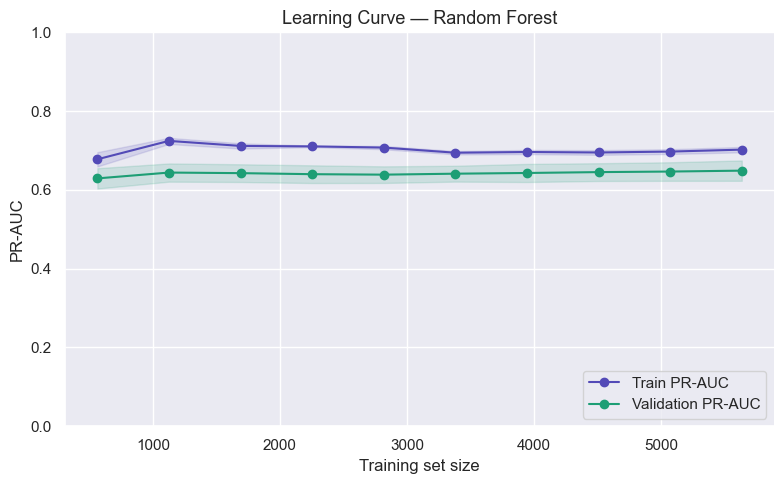

In [42]:
results_random_forest = train_random_forest_churn(
    pd.DataFrame(df_final),
    y,
    n_estimators=300,
    min_samples_leaf=20,
    max_features='sqrt',
    max_depth=None
)

In [43]:
results_random_forest['feature_importance']

,feature,importance
0,Contract_Month-to-month,0.177983
1,tenure,0.155714
2,OnlineSecurity_No,0.082893
3,Contract_Two year,0.080324
4,TechSupport_No,0.068342
5,InternetService_Fiber optic,0.062241
6,MonthlyCharges,0.056162
7,PaymentMethod_Electronic check,0.047914
8,Contract_One year,0.030661
9,OnlineBackup_No,0.021789


# 5. LGBM

In [44]:

def train_lightgbm_churn(
    X: pd.DataFrame,
    y: pd.Series,
    n_splits: int = 5,
    random_state: int = 42,
    **kwargs
) -> dict:
    """Trains a LightGBM model for churn prediction using stratified k-fold CV.

    Uses StratifiedKFold to preserve the churn rate across folds and
    scale_pos_weight to handle class imbalance without resampling. LightGBM
    handles categorical-encoded numeric features natively and does not require
    feature scaling. Early stopping is applied on PR-AUC evaluated on the
    validation fold to prevent overfitting and reduce training time.
    Feature importance is reported both as split count and gain, averaged
    across all folds.

    Args:
        X: Feature matrix. Must contain only numeric columns — encode categorical
            variables before calling this function. No scaling required.
        y: Binary target series. 1 = churned, 0 = retained.
        n_splits: Number of folds for StratifiedKFold cross-validation. Defaults to 5.
        random_state: Random seed for reproducibility. Defaults to 42.
        **kwargs: Additional keyword arguments passed to the LightGBM classifier.
            Lower values require more rounds but generalize better. Defaults to 0.05.

    Returns:
        A dict with the following keys:
            - "metrics" (pd.DataFrame): Per-fold scores for pr_auc, roc_auc,
              precision, recall, f1, and best_iteration.
            - "mean" (pd.Series): Mean of each metric across all folds.
            - "std" (pd.Series): Standard deviation of each metric across all folds.
            - "models" (list[lgb.Booster]): Fitted booster from each fold.
            - "feature_importance_split" (pd.DataFrame): Mean split-count importance
              per feature across all folds, sorted descending.
            - "feature_importance_gain" (pd.DataFrame): Mean gain importance per
              feature across all folds, sorted descending.
            - "learning_curve" (dict): Contains "train_sizes", "train_scores",
              and "val_scores" arrays used to plot the learning curve.

    Raises:
        ValueError: If X and y have different numbers of rows.
        ValueError: If y contains values other than 0 and 1.

    Example:
        >>> result = train_lightgbm_churn(X_encoded, y, n_splits=5)
        >>> print(result["mean"])
        >>> print(result["feature_importance_gain"].head(10))
    """
    # ── Input validation ───────────────────────────────────────────────────────

    if len(X) != len(y):
        raise ValueError(
            f"X and y must have the same number of rows. "
            f"Got X={len(X)}, y={len(y)}."
        )

    unique_values = set(y.unique())
    if not unique_values.issubset({0, 1}):
        raise ValueError(
            f"y must contain only binary values (0 and 1). "
            f"Got: {unique_values}."
        )

    # ── Cross-validation setup ─────────────────────────────────────────────────

    # StratifiedKFold preserves the churn rate in each fold,
    # which is critical for imbalanced targets.
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    # scale_pos_weight balances the gradient contribution of the minority class
    # (churners) relative to the majority class (retained customers).
    scale_pos_weight = (y == 0).sum() / (y == 1).sum()

    # Storage for per-fold results — tracked separately for train and val
    train_fold_metrics   = []
    val_fold_metrics     = []
    models               = []
    importance_split_matrix = []
    importance_gain_matrix  = []

    # ── Training loop ──────────────────────────────────────────────────────────

    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), start=1):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        # LightGBM native Dataset format — more memory efficient than numpy arrays
        dtrain = lgb.Dataset(X_train, label=y_train)
        dval   = lgb.Dataset(X_val,   label=y_val, reference=dtrain)

        params = {
            "objective":        "binary",
            "metric":           "average_precision",  # PR-AUC as early stopping metric
            "verbosity":        -1,           # suppress LightGBM training logs
            "n_jobs":           -1,
            **kwargs
        }

        callbacks = [
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=-1),
        ]

        model = lgb.train(
            params,
            dtrain,
            valid_sets=[dval],
            callbacks=callbacks
        )

        # ── Evaluation — train fold ────────────────────────────────────────────

        train_proba = model.predict(X_train)
        train_pred  = (train_proba >= 0.5).astype(int)

        train_fold_metrics.append({
            "fold":           fold,
            "pr_auc":         average_precision_score(y_train, train_proba),
            "roc_auc":        roc_auc_score(y_train, train_proba),
            "precision":      precision_score(y_train, train_pred, zero_division=0),
            "recall":         recall_score(y_train, train_pred, zero_division=0),
            "f1":             f1_score(y_train, train_pred, zero_division=0),
            "best_iteration": model.best_iteration,
        })

        # ── Evaluation — validation fold ──────────────────────────────────────

        val_proba = model.predict(X_val)

        # Default threshold of 0.5 for precision/recall/f1 —
        # threshold should be optimized separately via cost function.
        val_pred = (val_proba >= 0.5).astype(int)

        # PR-AUC is the primary metric for imbalanced churn datasets
        val_fold_metrics.append({
            "fold":           fold,
            "pr_auc":         average_precision_score(y_val, val_proba),
            "roc_auc":        roc_auc_score(y_val, val_proba),
            "precision":      precision_score(y_val, val_pred, zero_division=0),
            "recall":         recall_score(y_val, val_pred, zero_division=0),
            "f1":             f1_score(y_val, val_pred, zero_division=0),
            "best_iteration": model.best_iteration,
        })

        models.append(model)

        # LightGBM provides two importance types:
        # - split: number of times a feature is used to split a node
        # - gain: total reduction in loss from splits using the feature (more reliable)
        importance_split_matrix.append(
            model.feature_importance(importance_type="split")
        )
        importance_gain_matrix.append(
            model.feature_importance(importance_type="gain")
        )

        # Print full per-fold train and validation metrics
        print(f"Full metrics for fold {fold}:")
        print("  Train metrics:")
        for k, v in train_fold_metrics[-1].items():
            if k != "fold":
                print(f"    {k}: {v}")
        print("  Validation metrics:")
        for k, v in val_fold_metrics[-1].items():
            if k != "fold":
                print(f"    {k}: {v}")

    # ── Aggregate results ──────────────────────────────────────────────────────

    train_metrics_df = pd.DataFrame(train_fold_metrics).set_index("fold")
    val_metrics_df   = pd.DataFrame(val_fold_metrics).set_index("fold")

    train_mean = train_metrics_df.mean()
    train_std  = train_metrics_df.std()
    val_mean   = val_metrics_df.mean()
    val_std    = val_metrics_df.std()

    print("\n── Cross-validation summary ──────────────────────────")
    print(f"{'metric':>16} {'train mean':>12} {'train std':>10} {'val mean':>10} {'val std':>10}")
    print("-" * 62)
    for metric in val_metrics_df.columns:
        print(
            f"{metric:>16} "
            f"{train_mean[metric]:>12.4f} "
            f"{train_std[metric]:>10.4f} "
            f"{val_mean[metric]:>10.4f} "
            f"{val_std[metric]:>10.4f}"
        )

    # ── Feature importance ─────────────────────────────────────────────────────

    # Average importance across folds to reduce single-fold variance.
    # Gain importance is generally more informative than split count.
    def _build_importance_df(matrix: list[np.ndarray]) -> pd.DataFrame:
        return (
            pd.DataFrame({
                "feature":    X.columns,
                "importance": np.mean(matrix, axis=0),
            })
            .sort_values("importance", ascending=False)
            .reset_index(drop=True)
        )

    # ── Learning curve ─────────────────────────────────────────────────────────

    # LGBMClassifier wraps lgb.train in the sklearn API, making it compatible
    # with learning_curve. Parameters are mirrored from the training loop above.
    lc_model = lgb.LGBMClassifier(
        n_estimators=models[0].best_iteration,
        scale_pos_weight=scale_pos_weight,
        random_state=random_state,
        verbosity=-1,
        n_jobs=-1,
    )

    train_sizes, train_scores, val_scores = learning_curve(
        estimator=lc_model,
        X=X,
        y=y,
        cv=StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state),
        scoring="average_precision",   # PR-AUC — consistent with primary metric
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1,
    )

    plot_learning_curve(
        train_sizes=train_sizes,
        train_scores=train_scores,
        val_scores=val_scores,
        title="Learning Curve — LightGBM",
    )

    return {
        "train_metrics":             train_metrics_df,
        "val_metrics":               val_metrics_df,
        "train_mean":                train_mean,
        "val_mean":                  val_mean,
        "train_std":                 train_std,
        "val_std":                   val_std,
        "models":                    models,
        "feature_importance_split":  _build_importance_df(importance_split_matrix),
        "feature_importance_gain":   _build_importance_df(importance_gain_matrix),
        "learning_curve": {
            "train_sizes":  train_sizes,
            "train_scores": train_scores,
            "val_scores":   val_scores,
        },
    }

Full metrics for fold 1:
  Train metrics:
    pr_auc: 0.7383184695346069
    roc_auc: 0.8849058753467505
    precision: 0.7304270462633452
    recall: 0.5491638795986622
    f1: 0.6269568537609774
    best_iteration: 24
  Validation metrics:
    pr_auc: 0.6795287508413628
    roc_auc: 0.8581260172053011
    precision: 0.6819787985865724
    recall: 0.516042780748663
    f1: 0.5875190258751902
    best_iteration: 24
Full metrics for fold 2:
  Train metrics:
    pr_auc: 0.8049688349205347
    roc_auc: 0.9229136179953958
    precision: 0.7660079051383399
    recall: 0.6481605351170568
    f1: 0.7021739130434783
    best_iteration: 62
  Validation metrics:
    pr_auc: 0.6499519805334866
    roc_auc: 0.8356196233434086
    precision: 0.639751552795031
    recall: 0.5508021390374331
    f1: 0.5919540229885057
    best_iteration: 62
Full metrics for fold 3:
  Train metrics:
    pr_auc: 0.7459339761106624
    roc_auc: 0.8919825366183969
    precision: 0.7337434094903339
    recall: 0.558528428

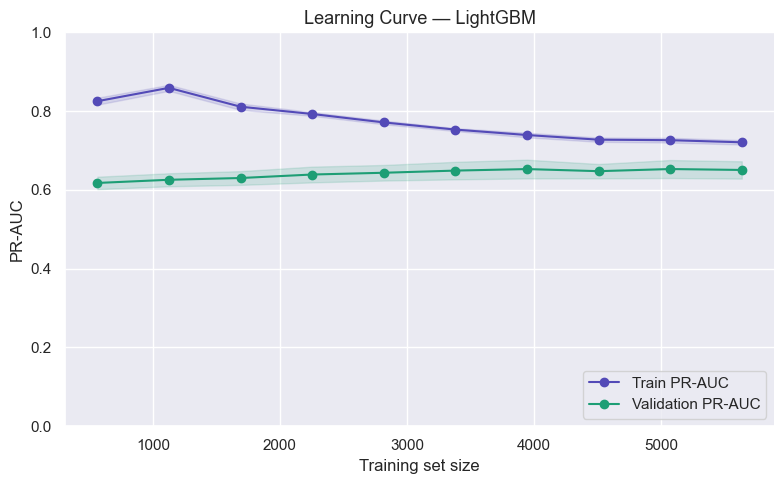

In [45]:
results_lgbm = train_lightgbm_churn(pd.DataFrame(df_final), y)

In [46]:
results_lgbm['feature_importance_gain']

,feature,importance
0,Contract_Month-to-month,5322.530927
1,tenure,2289.420630
2,MonthlyCharges,1855.446797
3,InternetService_Fiber optic,719.806613
4,OnlineSecurity_No,610.674207
5,TechSupport_No,356.640559
6,PaymentMethod_Electronic check,287.594800
7,PaperlessBilling,226.131235
8,Contract_Two year,220.141897
9,Contract_One year,210.618382


# 6. XGBoost

In [47]:

def train_xgboost_churn(
    X: pd.DataFrame,
    y: pd.Series,
    n_splits: int = 5,
    random_state: int = 42,
    **kwargs
) -> dict:
    """Trains an XGBoost model for churn prediction using stratified k-fold CV.

    Uses StratifiedKFold to preserve the churn rate across folds and
    scale_pos_weight to handle class imbalance without resampling. XGBoost
    does not require feature scaling. Early stopping is applied on PR-AUC
    evaluated on the validation fold to prevent overfitting and reduce
    training time. Feature importance is reported both as weight (split count)
    and gain, averaged across all folds.

    Args:
        X: Feature matrix. Must contain only numeric columns — encode categorical
            variables before calling this function. No scaling required.
        y: Binary target series. 1 = churned, 0 = retained.
        n_splits: Number of folds for StratifiedKFold cross-validation. Defaults to 5.
        random_state: Random seed for reproducibility. Defaults to 42.
        **kwargs: Additional keyword arguments passed to the XGBoost classifier.

    Returns:
        A dict with the following keys:
            - "train_metrics" (pd.DataFrame): Per-fold scores on the training fold.
            - "val_metrics" (pd.DataFrame): Per-fold scores on the validation fold.
            - "train_mean" (pd.Series): Mean of each train metric across all folds.
            - "val_mean" (pd.Series): Mean of each val metric across all folds.
            - "train_std" (pd.Series): Std of each train metric across all folds.
            - "val_std" (pd.Series): Std of each val metric across all folds.
            - "models" (list[xgb.Booster]): Fitted booster from each fold.
            - "feature_importance_weight" (pd.DataFrame): Mean split-count importance
              per feature across all folds, sorted descending.
            - "feature_importance_gain" (pd.DataFrame): Mean gain importance per
              feature across all folds, sorted descending.
            - "learning_curve" (dict): Contains "train_sizes", "train_scores",
              and "val_scores" arrays used to plot the learning curve.

    Raises:
        ValueError: If X and y have different numbers of rows.
        ValueError: If y contains values other than 0 and 1.

    Example:
        >>> result = train_xgboost_churn(X_encoded, y, n_splits=5)
        >>> print(result["val_mean"])
        >>> print(result["feature_importance_gain"].head(10))
    """
    # ── Input validation ───────────────────────────────────────────────────────

    if len(X) != len(y):
        raise ValueError(
            f"X and y must have the same number of rows. "
            f"Got X={len(X)}, y={len(y)}."
        )

    unique_values = set(y.unique())
    if not unique_values.issubset({0, 1}):
        raise ValueError(
            f"y must contain only binary values (0 and 1). "
            f"Got: {unique_values}."
        )

    # ── Cross-validation setup ─────────────────────────────────────────────────

    # StratifiedKFold preserves the churn rate in each fold,
    # which is critical for imbalanced targets.
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    # scale_pos_weight balances the gradient contribution of the minority class
    # (churners) relative to the majority class (retained customers).
    scale_pos_weight = (y == 0).sum() / (y == 1).sum()

    # Storage for per-fold results — tracked separately for train and val
    train_fold_metrics      = []
    val_fold_metrics        = []
    models                  = []
    importance_weight_matrix = []
    importance_gain_matrix   = []

    # ── Training loop ──────────────────────────────────────────────────────────

    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), start=1):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        # XGBoost native DMatrix format — more memory efficient than numpy arrays
        dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=list(X.columns))
        dval   = xgb.DMatrix(X_val,   label=y_val,   feature_names=list(X.columns))

        params = {
            "objective":        "binary:logistic",
            "eval_metric":      "aucpr",          # PR-AUC as early stopping metric
            "seed":             random_state,
            "verbosity":        0,                # suppress XGBoost training logs
            "scale_pos_weight": scale_pos_weight,
            "nthread":          -1,
            **kwargs
        }

        # evals_result stores per-round metric history — useful for diagnostics
        evals_result: dict = {}

        model = xgb.train(
            params,
            dtrain,
            evals=[(dtrain, "train"), (dval, "val")],
            evals_result=evals_result,
            verbose_eval=False,
            early_stopping_rounds=50
        )

        # ── Evaluation — train fold ────────────────────────────────────────────

        train_proba = model.predict(dtrain)
        train_pred  = (train_proba >= 0.5).astype(int)

        train_fold_metrics.append({
            "fold":           fold,
            "pr_auc":         average_precision_score(y_train, train_proba),
            "roc_auc":        roc_auc_score(y_train, train_proba),
            "precision":      precision_score(y_train, train_pred, zero_division=0),
            "recall":         recall_score(y_train, train_pred, zero_division=0),
            "f1":             f1_score(y_train, train_pred, zero_division=0),
            "best_iteration": model.best_iteration,
        })

        # ── Evaluation — validation fold ──────────────────────────────────────

        val_proba = model.predict(dval)

        # Default threshold of 0.5 for precision/recall/f1 —
        # threshold should be optimized separately via cost function.
        val_pred = (val_proba >= 0.5).astype(int)

        # PR-AUC is the primary metric for imbalanced churn datasets
        val_fold_metrics.append({
            "fold":           fold,
            "pr_auc":         average_precision_score(y_val, val_proba),
            "roc_auc":        roc_auc_score(y_val, val_proba),
            "precision":      precision_score(y_val, val_pred, zero_division=0),
            "recall":         recall_score(y_val, val_pred, zero_division=0),
            "f1":             f1_score(y_val, val_pred, zero_division=0),
            "best_iteration": model.best_iteration,
        })

        models.append(model)

        # XGBoost provides two importance types:
        # - weight: number of times a feature is used to split a node
        # - gain: average gain across all splits that use the feature (more reliable)
        importance_weight_matrix.append(
            np.array([
                model.get_score(importance_type="weight").get(f, 0)
                for f in X.columns
            ])
        )
        importance_gain_matrix.append(
            np.array([
                model.get_score(importance_type="gain").get(f, 0)
                for f in X.columns
            ])
        )

        train_metrics = train_fold_metrics[-1]
        val_metrics = val_fold_metrics[-1]

        print(
            f"  Train metrics: PR-AUC={train_metrics['pr_auc']:.4f},\n"
            f"ROC-AUC={train_metrics['roc_auc']:.4f},\n"
            f"Precision={train_metrics['precision']:.4f},\n "
            f"Recall={train_metrics['recall']:.4f},\n "
            f"F1={train_metrics['f1']:.4f},\n "
            f"Best iter={train_metrics['best_iteration']}\n"
        )
        print(
            f"  Validation metrics: PR-AUC={val_metrics['pr_auc']:.4f},\n "
            f"ROC-AUC={val_metrics['roc_auc']:.4f},\n "
            f"Precision={val_metrics['precision']:.4f},\n "
            f"Recall={val_metrics['recall']:.4f},\n "
            f"F1={val_metrics['f1']:.4f},\n "
            f"Best iter={val_metrics['best_iteration']}\n"
        )

    # ── Aggregate results ──────────────────────────────────────────────────────

    train_metrics_df = pd.DataFrame(train_fold_metrics).set_index("fold")
    val_metrics_df   = pd.DataFrame(val_fold_metrics).set_index("fold")

    train_mean = train_metrics_df.mean()
    train_std  = train_metrics_df.std()
    val_mean   = val_metrics_df.mean()
    val_std    = val_metrics_df.std()

    print("\n── Cross-validation summary ──────────────────────────")
    print(f"{'metric':>16} {'train mean':>12} {'train std':>10} {'val mean':>10} {'val std':>10}")
    print("-" * 62)
    for metric in val_metrics_df.columns:
        print(
            f"{metric:>16} "
            f"{train_mean[metric]:>12.4f} "
            f"{train_std[metric]:>10.4f} "
            f"{val_mean[metric]:>10.4f} "
            f"{val_std[metric]:>10.4f}"
        )

    # ── Feature importance ─────────────────────────────────────────────────────

    # Average importance across folds to reduce single-fold variance.
    # Gain importance is generally more informative than weight count.
    def _build_importance_df(matrix: list[np.ndarray]) -> pd.DataFrame:
        return (
            pd.DataFrame({
                "feature":    X.columns,
                "importance": np.mean(matrix, axis=0),
            })
            .sort_values("importance", ascending=False)
            .reset_index(drop=True)
        )

    # ── Learning curve ─────────────────────────────────────────────────────────

    # XGBClassifier wraps xgb.train in the sklearn API, making it compatible
    # with learning_curve. Use mean best_iteration from CV folds to avoid
    # the n_estimators=0 error that occurs when best_iteration is not set.
    best_iter = max(1, int(np.mean([m.best_iteration for m in models])))


    if kwargs.get("n_estimators") is not None:
        print(f"Using n_estimators={kwargs['n_estimators']} for learning curve instead of best_iteration={best_iter}.")

        lc_model = xgb.XGBClassifier(
            scale_pos_weight=scale_pos_weight,
            random_state=random_state,
            verbosity=0,
            n_jobs=-1,
            eval_metric="aucpr",
            **kwargs
        )
    else:
        lc_model = xgb.XGBClassifier(
            n_estimators=best_iter,
            scale_pos_weight=scale_pos_weight,
            random_state=random_state,
            verbosity=0,
            n_jobs=-1,
            eval_metric="aucpr",
            **kwargs
        )

    train_sizes, train_scores, val_scores = learning_curve(
        estimator=lc_model,
        X=X,
        y=y,
        cv=StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state),
        scoring="average_precision",   # PR-AUC — consistent with primary metric
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1,
    )

    plot_learning_curve(
        train_sizes=train_sizes,
        train_scores=train_scores,
        val_scores=val_scores,
        title="Learning Curve — XGBoost",
    )

    return {
        "train_metrics":              train_metrics_df,
        "val_metrics":                val_metrics_df,
        "train_mean":                 train_mean,
        "val_mean":                   val_mean,
        "train_std":                  train_std,
        "val_std":                    val_std,
        "models":                     models,
        "feature_importance_weight":  _build_importance_df(importance_weight_matrix),
        "feature_importance_gain":    _build_importance_df(importance_gain_matrix),
        "learning_curve": {
            "train_sizes":  train_sizes,
            "train_scores": train_scores,
            "val_scores":   val_scores,
        },
    }

  Train metrics: PR-AUC=0.7362,
ROC-AUC=0.8968,
Precision=0.5744,
 Recall=0.8702,
 F1=0.6920,
 Best iter=8

  Validation metrics: PR-AUC=0.6747,
 ROC-AUC=0.8532,
 Precision=0.5344,
 Recall=0.7888,
 F1=0.6371,
 Best iter=8

  Train metrics: PR-AUC=0.7431,
ROC-AUC=0.8992,
Precision=0.5770,
 Recall=0.8595,
 F1=0.6905,
 Best iter=5

  Validation metrics: PR-AUC=0.6378,
 ROC-AUC=0.8336,
 Precision=0.5095,
 Recall=0.7914,
 F1=0.6199,
 Best iter=5

  Train metrics: PR-AUC=0.7437,
ROC-AUC=0.8994,
Precision=0.5758,
 Recall=0.8736,
 F1=0.6941,
 Best iter=3

  Validation metrics: PR-AUC=0.6674,
 ROC-AUC=0.8417,
 Precision=0.5332,
 Recall=0.7727,
 F1=0.6310,
 Best iter=3

  Train metrics: PR-AUC=0.7512,
ROC-AUC=0.9017,
Precision=0.5752,
 Recall=0.8770,
 F1=0.6947,
 Best iter=9

  Validation metrics: PR-AUC=0.6200,
 ROC-AUC=0.8254,
 Precision=0.5114,
 Recall=0.7828,
 F1=0.6186,
 Best iter=9

  Train metrics: PR-AUC=0.7548,
ROC-AUC=0.9021,
Precision=0.5955,
 Recall=0.8615,
 F1=0.7042,
 Best iter=6



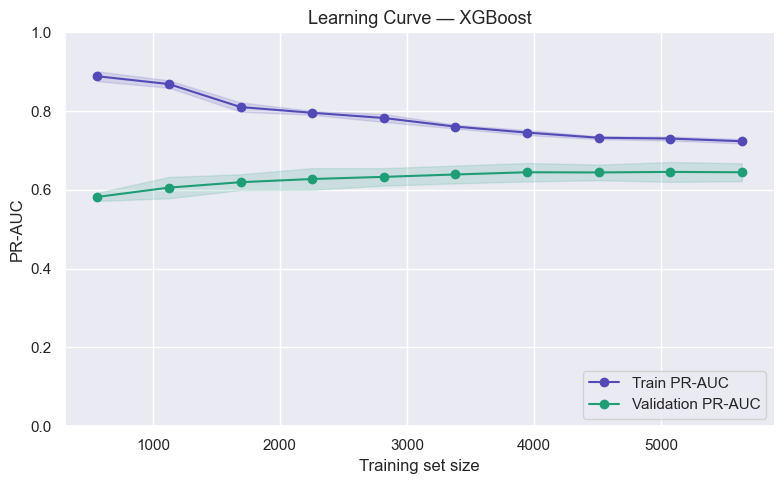

In [48]:
results_xgboost = train_xgboost_churn(pd.DataFrame(df_final), y)

In [49]:
results_xgboost['feature_importance_weight']

,feature,importance
0,MonthlyCharges,167.8
1,tenure,142.8
2,PaymentMethod_Electronic check,23.0
3,PaperlessBilling,21.8
4,SeniorCitizen,19.6
5,TechSupport_No,17.6
6,OnlineSecurity_No,17.6
7,OnlineBackup_No,14.8
8,Dependents,12.6
9,Contract_One year,11.4


# 7. SVC

In [50]:

def train_svm_churn(
    X: pd.DataFrame,
    y: pd.Series,
    n_splits: int = 5,
    random_state: int = 42,
    C: float = 1.0,
    kernel: str = "rbf",
    gamma: str = "scale",
    degree: int = 3,
) -> dict:
    """Trains an SVM model for churn prediction using stratified k-fold CV.

    Uses StratifiedKFold to preserve the churn rate across folds,
    MinMaxScaler for feature normalization (mandatory for SVM — the algorithm
    is sensitive to feature magnitude), and class_weight='balanced' to handle
    class imbalance without resampling. Probability estimates are enabled via
    Platt scaling (probability=True), which allows PR-AUC computation but
    increases training time. Because SVM does not produce native feature
    importances, a permutation-based proxy is not computed — the returned
    feature_importance key is None.

    Note:
        SVM scales poorly with large datasets (O(n²) to O(n³) in training time).
        For datasets above ~10k rows, consider using LinearSVC with
        CalibratedClassifierCV instead, or prefer LightGBM/XGBoost.

    Args:
        X: Feature matrix. Must contain only numeric columns — encode categorical
            variables before calling this function.
        y: Binary target series. 1 = churned, 0 = retained.
        n_splits: Number of folds for StratifiedKFold cross-validation. Defaults to 5.
        random_state: Random seed for reproducibility. Defaults to 42.
        C: Regularization parameter. Smaller values apply stronger regularization
            (larger margin, more misclassifications allowed). Defaults to 1.0.
        kernel: Kernel type. One of 'rbf', 'linear', 'poly', 'sigmoid'.
            'rbf' is the standard choice for non-linear churn patterns. Defaults
            to 'rbf'.
        gamma: Kernel coefficient for 'rbf', 'poly', and 'sigmoid'. 'scale' uses
            1 / (n_features * X.var()), 'auto' uses 1 / n_features. Defaults
            to 'scale'.
        degree: Degree of the polynomial kernel. Ignored by all other kernels.
            Defaults to 3.

    Returns:
        A dict with the following keys:
            - "train_metrics" (pd.DataFrame): Per-fold scores on the training fold.
            - "val_metrics" (pd.DataFrame): Per-fold scores on the validation fold.
            - "train_mean" (pd.Series): Mean of each train metric across all folds.
            - "val_mean" (pd.Series): Mean of each val metric across all folds.
            - "train_std" (pd.Series): Std of each train metric across all folds.
            - "val_std" (pd.Series): Std of each val metric across all folds.
            - "models" (list[Pipeline]): Fitted Pipeline(scaler + SVC) from each fold.
            - "feature_importance" (None): SVM does not produce native feature
              importances. Use SHAP with kernel explainer for post-hoc attribution.
            - "learning_curve" (dict): Contains "train_sizes", "train_scores",
              and "val_scores" arrays used to plot the learning curve.

    Raises:
        ValueError: If X and y have different numbers of rows.
        ValueError: If y contains values other than 0 and 1.

    Example:
        >>> result = train_svm_churn(X_encoded, y, n_splits=5, C=1.0, kernel='rbf')
        >>> print(result["val_mean"])
    """
    # ── Input validation ───────────────────────────────────────────────────────

    if len(X) != len(y):
        raise ValueError(
            f"X and y must have the same number of rows. "
            f"Got X={len(X)}, y={len(y)}."
        )

    unique_values = set(y.unique())
    if not unique_values.issubset({0, 1}):
        raise ValueError(
            f"y must contain only binary values (0 and 1). "
            f"Got: {unique_values}."
        )

    # ── Cross-validation setup ─────────────────────────────────────────────────

    # StratifiedKFold preserves the churn rate in each fold,
    # which is critical for imbalanced targets.
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    # Storage for per-fold results — tracked separately for train and val
    train_fold_metrics = []
    val_fold_metrics   = []
    models             = []

    # ── Training loop ──────────────────────────────────────────────────────────

    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), start=1):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        # Pipeline wraps scaler + SVC so that MinMaxScaler is fit only on the
        # training fold — applying it before the split would cause data leakage.
        # probability=True enables predict_proba via Platt scaling, required
        # for PR-AUC and ROC-AUC computation.
        pipeline = Pipeline([
            ("scaler", MinMaxScaler()),
            ("clf", SVC(
                # C=C,
                # kernel=kernel,
                # gamma=gamma,
                # degree=degree,
                class_weight="balanced",
                probability=True,
                random_state=random_state,
            )),
        ])
        pipeline.fit(X_train, y_train)

        # ── Evaluation — train fold ────────────────────────────────────────────

        train_proba = pipeline.predict_proba(X_train)[:, 1]
        train_pred  = pipeline.predict(X_train)

        train_fold_metrics.append({
            "fold":      fold,
            "pr_auc":    average_precision_score(y_train, train_proba),
            "roc_auc":   roc_auc_score(y_train, train_proba),
            "precision": precision_score(y_train, train_pred, zero_division=0),
            "recall":    recall_score(y_train, train_pred, zero_division=0),
            "f1":        f1_score(y_train, train_pred, zero_division=0),
        })

        # ── Evaluation — validation fold ──────────────────────────────────────

        val_proba = pipeline.predict_proba(X_val)[:, 1]
        val_pred  = pipeline.predict(X_val)

        # PR-AUC is the primary metric for imbalanced churn datasets
        val_fold_metrics.append({
            "fold":      fold,
            "pr_auc":    average_precision_score(y_val, val_proba),
            "roc_auc":   roc_auc_score(y_val, val_proba),
            "precision": precision_score(y_val, val_pred, zero_division=0),
            "recall":    recall_score(y_val, val_pred, zero_division=0),
            "f1":        f1_score(y_val, val_pred, zero_division=0),
        })

        models.append(pipeline)

        print(
            f"Fold {fold}/{n_splits} — "
            f"Train PR-AUC: {train_fold_metrics[-1]['pr_auc']:.4f} | "
            f"Val PR-AUC: {val_fold_metrics[-1]['pr_auc']:.4f} | "
            f"Val Precision: {val_fold_metrics[-1]['precision']:.4f} | "
            f"Val Recall: {val_fold_metrics[-1]['recall']:.4f}"
        )

    # ── Aggregate results ──────────────────────────────────────────────────────

    train_metrics_df = pd.DataFrame(train_fold_metrics).set_index("fold")
    val_metrics_df   = pd.DataFrame(val_fold_metrics).set_index("fold")

    train_mean = train_metrics_df.mean()
    train_std  = train_metrics_df.std()
    val_mean   = val_metrics_df.mean()
    val_std    = val_metrics_df.std()

    print("\n── Cross-validation summary ──────────────────────────")
    print(f"{'metric':>16} {'train mean':>12} {'train std':>10} {'val mean':>10} {'val std':>10}")
    print("-" * 62)
    for metric in val_metrics_df.columns:
        print(
            f"{metric:>16} "
            f"{train_mean[metric]:>12.4f} "
            f"{train_std[metric]:>10.4f} "
            f"{val_mean[metric]:>10.4f} "
            f"{val_std[metric]:>10.4f}"
        )

    # ── Learning curve ─────────────────────────────────────────────────────────

    # Pipeline is reused directly — MinMaxScaler is correctly re-fit on each
    # training subset by learning_curve, avoiding data leakage across subset sizes.
    lc_pipeline = Pipeline([
        ("scaler", MinMaxScaler()),
        ("clf", SVC(
            # C=C,
            # kernel=kernel,
            # gamma=gamma,
            # degree=degree,
            class_weight="balanced",
            probability=True,
            random_state=random_state,
        )),
    ])

    train_sizes, train_scores, val_scores = learning_curve(
        estimator=lc_pipeline,
        X=X,
        y=y,
        cv=StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state),
        scoring="average_precision",   # PR-AUC — consistent with primary metric
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1,
    )

    plot_learning_curve(
        train_sizes=train_sizes,
        train_scores=train_scores,
        val_scores=val_scores,
        title="Learning Curve — SVC",
    )

    return {
        "train_metrics":    train_metrics_df,
        "val_metrics":      val_metrics_df,
        "train_mean":       train_mean,
        "val_mean":         val_mean,
        "train_std":        train_std,
        "val_std":          val_std,
        "models":           models,
        # SVM does not produce native feature importances.
        # Use SHAP KernelExplainer for post-hoc attribution if needed.
        "feature_importance": None,
        "learning_curve": {
            "train_sizes":  train_sizes,
            "train_scores": train_scores,
            "val_scores":   val_scores,
        },
    }

Fold 1/5 — Train PR-AUC: 0.6375 | Val PR-AUC: 0.5754 | Val Precision: 0.5196 | Val Recall: 0.7807
Fold 2/5 — Train PR-AUC: 0.6543 | Val PR-AUC: 0.5938 | Val Precision: 0.5025 | Val Recall: 0.8128
Fold 3/5 — Train PR-AUC: 0.6233 | Val PR-AUC: 0.5899 | Val Precision: 0.5104 | Val Recall: 0.7888
Fold 4/5 — Train PR-AUC: 0.6617 | Val PR-AUC: 0.5494 | Val Precision: 0.4991 | Val Recall: 0.7560
Fold 5/5 — Train PR-AUC: 0.6480 | Val PR-AUC: 0.5573 | Val Precision: 0.5035 | Val Recall: 0.7754

── Cross-validation summary ──────────────────────────
          metric   train mean  train std   val mean    val std
--------------------------------------------------------------
          pr_auc       0.6450     0.0150     0.5732     0.0195
         roc_auc       0.8643     0.0051     0.8174     0.0155
       precision       0.5291     0.0050     0.5070     0.0081
          recall       0.8177     0.0108     0.7828     0.0207
              f1       0.6424     0.0050     0.6153     0.0093


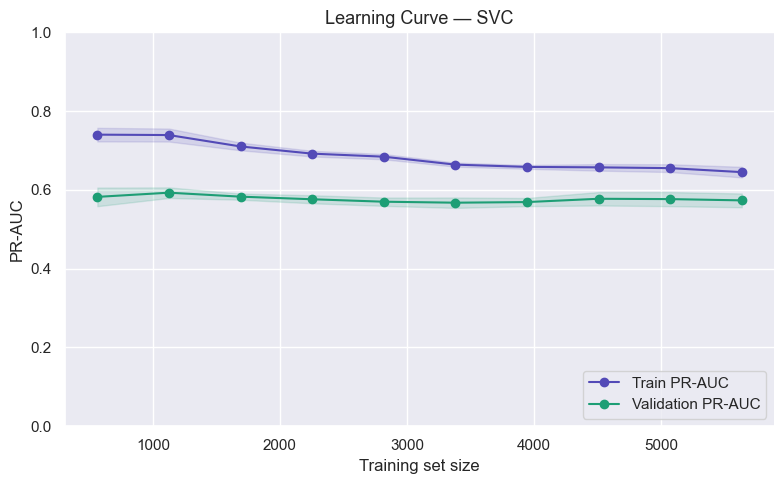

In [51]:
results_svc = train_svm_churn(pd.DataFrame(df_final), y)

# 8. Compare Results

## 8. 1. Train/Test Metrics

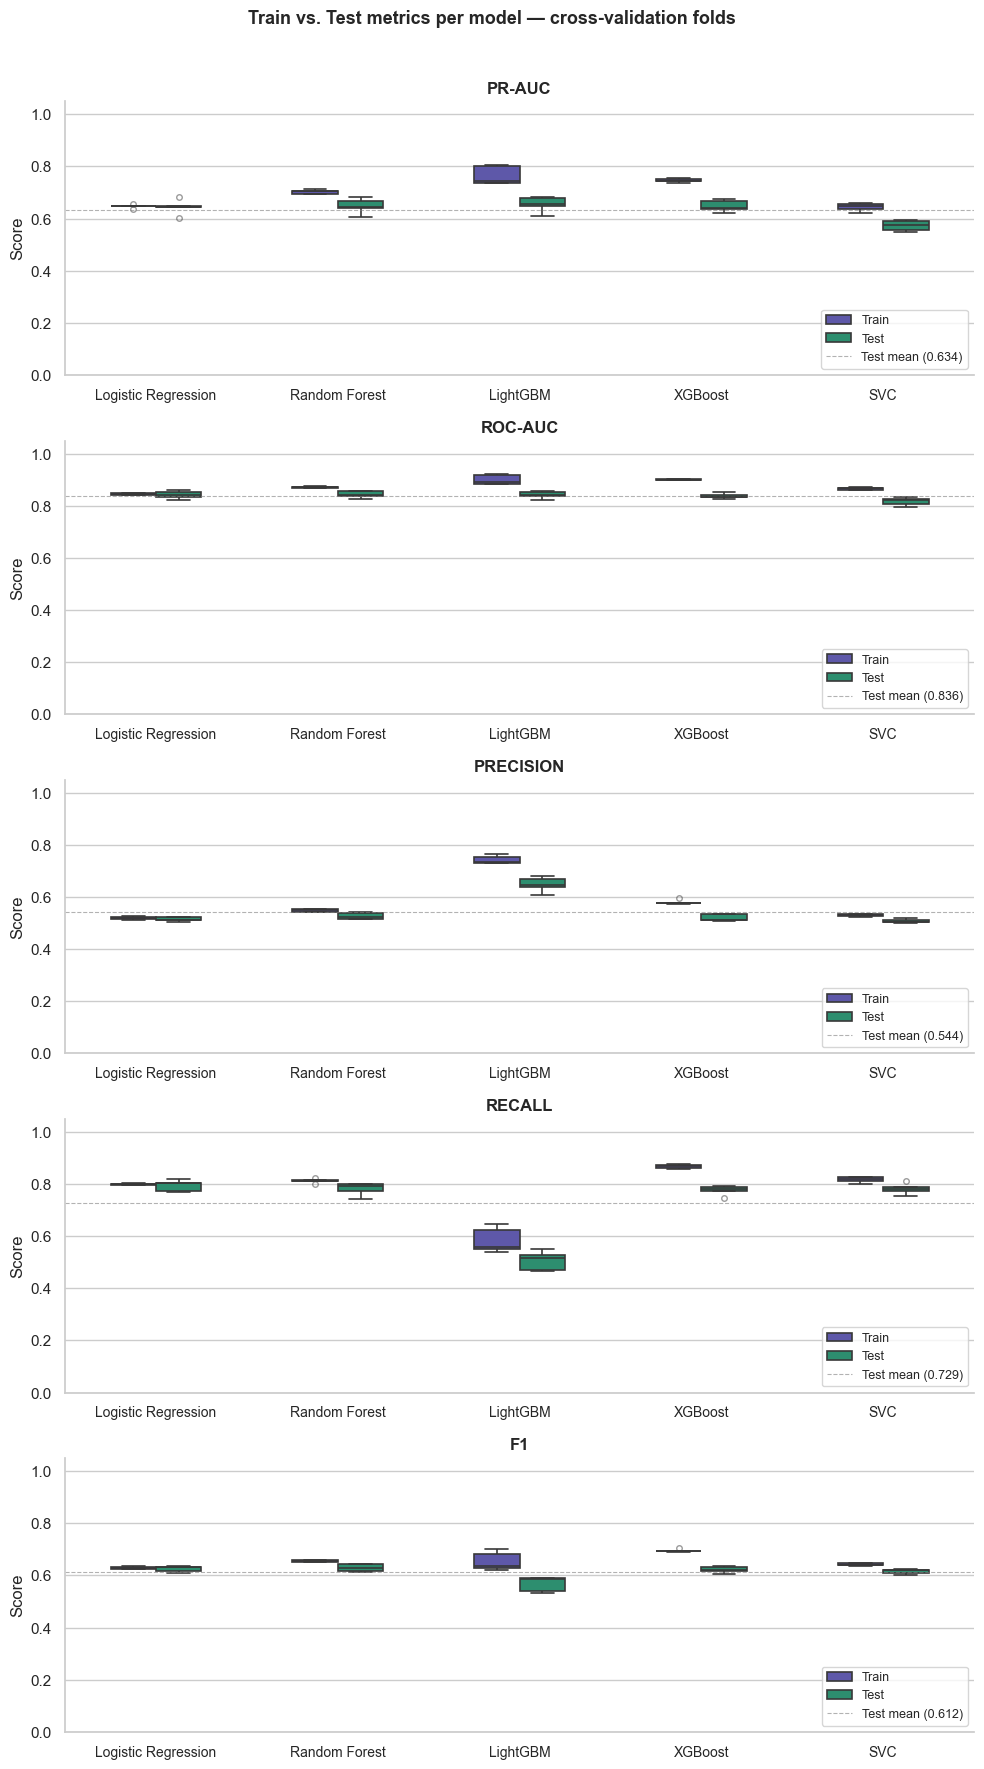

In [52]:
# ── Configuration ──────────────────────────────────────────────────────────────
 
# Map display name → result dict returned by each train_*_churn function
results = {
    "Logistic Regression": results_logistic_regression,
    "Random Forest":       results_random_forest,
    "LightGBM":            results_lgbm,
    "XGBoost":             results_xgboost,
    "SVC":                 results_svc,
}
 
metrics = ["pr_auc", "roc_auc", "precision", "recall", "f1"]
 
# ── Build long-format DataFrame ────────────────────────────────────────────────
 
records = []
 
for model_name, result in results.items():
    for split, key in [("Train", "train_metrics"), ("Test", "val_metrics")]:
        df_metrics = result[key].copy()
 
        # Drop non-metric columns present in some models (e.g. best_iteration)
        available_metrics = [m for m in metrics if m in df_metrics.columns]
        df_metrics = df_metrics[available_metrics]
 
        for fold_idx, row in df_metrics.iterrows():
            for metric, value in row.items():
                records.append({
                    "model":  model_name,
                    "split":  split,
                    "metric": metric,
                    "value":  value,
                    "fold":   fold_idx,
                })
 
plot_df = pd.DataFrame(records)
 
# ── Plot ───────────────────────────────────────────────────────────────────────
 
sns.set_theme(style="whitegrid", palette="muted")
 
n_metrics = len(metrics)
fig, axes = plt.subplots(
    nrows=n_metrics,
    ncols=1,
    figsize=(max(10, len(results) * 2), n_metrics * 3.5),
)
 
palette = {"Train": "#534AB7", "Test": "#1D9E75"}
 
for ax, metric in zip(axes, metrics):
    metric_df = plot_df[plot_df["metric"] == metric]
 
    sns.boxplot(
        data=metric_df,
        x="model",
        y="value",
        hue="split",
        palette=palette,
        width=0.5,
        linewidth=1.2,
        flierprops={"marker": "o", "markersize": 4, "alpha": 0.5},
        ax=ax,
    )
 
    # Reference line at the overall validation mean across all models
    val_mean = metric_df[metric_df["split"] == "Test"]["value"].mean()
    ax.axhline(
        y=val_mean,
        color="gray",
        linestyle="--",
        linewidth=0.8,
        alpha=0.6,
        label=f"Test mean ({val_mean:.3f})",
    )
 
    ax.set_title(metric.upper().replace("_", "-"), fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.legend(loc="lower right", fontsize=9)
    ax.tick_params(axis="x", labelsize=10)
    sns.despine(ax=ax)
 
fig.suptitle(
    "Train vs. Test metrics per model — cross-validation folds",
    fontsize=13,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()

In [53]:
metrics = ["pr_auc", "roc_auc", "precision", "recall", "f1"]
 
# ── Build summary tables ───────────────────────────────────────────────────────
 
train_summary = pd.DataFrame({
    model_name: result["train_metrics"][
        [m for m in metrics if m in result["train_metrics"].columns]
    ].mean()
    for model_name, result in results.items()
}).T
 
val_summary = pd.DataFrame({
    model_name: result["val_metrics"][
        [m for m in metrics if m in result["val_metrics"].columns]
    ].mean()
    for model_name, result in results.items()
}).T
 
# ── Display ────────────────────────────────────────────────────────────────────
 
print("=" * 62)
print("TRAIN — mean metrics across CV folds")
print("=" * 62)
display(train_summary.style.highlight_max(axis=0, color="#ffffff"))
 
print()
 
print("=" * 62)
print("TEST — mean metrics across CV folds")
print("=" * 62)
display(val_summary.style.highlight_max(axis=0, color="#ffffff"))

TRAIN — mean metrics across CV folds


,pr_auc,roc_auc,precision,recall,f1
Logistic Regression,0.647341,0.845178,0.519767,0.799625,0.630007
Random Forest,0.702702,0.871379,0.548868,0.812334,0.655068
LightGBM,0.765108,0.900658,0.743215,0.583863,0.653468
XGBoost,0.745812,0.899836,0.579579,0.868378,0.695116
SVC,0.644980,0.864269,0.529071,0.817682,0.642420



TEST — mean metrics across CV folds


,pr_auc,roc_auc,precision,recall,f1
Logistic Regression,0.644780,0.842300,0.514524,0.795064,0.624698
Random Forest,0.648630,0.843672,0.527931,0.782215,0.630266
LightGBM,0.655569,0.841440,0.649073,0.506135,0.568269
XGBoost,0.648208,0.837195,0.519894,0.776354,0.622643
SVC,0.573184,0.817433,0.507004,0.782757,0.615305


Considering all models except LightGBM, their behavior is relatively similar: they present lower precision (slightly above 50%) and higher recall (close to 80%). This indicates that, on the test sets, the models were able to identify most customers who would churn, but at the cost of generating a high number of churn predictions. This is not necessarily an issue if the operational cost of targeting customers classified as potential churn cases is not significant.

LightGBM, on the other hand, achieved higher precision (close to 65%) but a recall of approximately 50%. This means that it failed to identify more than half of the customers who actually churned in the test set. Therefore, despite achieving the highest PR-AUC, this result may be misleading, as the apparent balance is largely driven by improved precision at the expense of missing a substantial portion of actual churn cases.

Considering all evaluation metrics, the most reliable model appears to be the RandomForestClassifier. On the test set, it achieved the best PR-AUC among all models except LightGBM, the highest ROC-AUC, the second-best precision after LightGBM, average recall performance, and the highest F1-score.

## 8. 2. Business KPIs

In [ ]:
results = {
    "Logistic Regression": result,
    "Random Forest":       results_random_forest,
    "LightGBM":            results_lgbm,
    "XGBoost":             results_xgboost,
    "SVM":                 results_svc,
}

THRESHOLD       = 0.5   # churn probability cutoff
SAVE_RATE       = 0.30  # % of contacted customers successfully retained
COST_PER_ACTION = 15.0  # cost per retention action
FOLD_IDX        = -1     # which CV fold to use

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
splits = list(cv.split(df_final, y))
_, val_idx = splits[FOLD_IDX]

X_val = df_final.iloc[val_idx]
y_val = y.iloc[val_idx]

# Financial data for the validation fold
val_financial = df.loc[val_idx, :].copy()
val_financial["churn_real"] = y_val.values

# Baseline metrics (no model — no retention action)
n_total          = len(val_financial)
churn_rate_base  = val_financial["churn_real"].mean()
mrr_base         = val_financial["MonthlyCharges"].sum()
mrr_lost_base    = val_financial[val_financial["churn_real"] == 1]["MonthlyCharges"].sum()
mrr_retained_base = mrr_base - mrr_lost_base
ltv_base         = (val_financial["MonthlyCharges"] * val_financial["tenure"]).sum()

records = []

# Baseline row — no model, no action
records.append({
    "model":            "Baseline (no action)",
    "churners_avoided": 0,
    "churn_rate":       round(churn_rate_base, 4),
    "mrr_total":        round(mrr_base, 2),
    "mrr_retained":     round(mrr_retained_base, 2),
    "mrr_lost":         round(mrr_lost_base, 2),
    "ltv_total":        round(ltv_base, 2),
})

for model_name, res in results.items():
    model = res["models"][FOLD_IDX]

    if hasattr(model, "predict_proba"):
        churn_score = model.predict_proba(X_val)[:, 1]
    elif isinstance(model, lgb.Booster):
        churn_score = model.predict(X_val)
    elif isinstance(model, xgb.Booster):
        dval = xgb.DMatrix(X_val, feature_names=list(X_val.columns))
        churn_score = model.predict(dval)
    else:
        raise TypeError(f"Unsupported model type: {type(model)}")

    churn_pred = (churn_score >= THRESHOLD).astype(int)

    eval_df = val_financial.copy()
    eval_df["churn_score"] = churn_score
    eval_df["churn_pred"]  = churn_pred

    # ── Simulate retention outcome ─────────────────────────────────────────────

    # True positives: correctly flagged churners — SAVE_RATE of them are retained
    true_pos_mask  = (eval_df["churn_pred"] == 1) & (eval_df["churn_real"] == 1)
    false_pos_mask = (eval_df["churn_pred"] == 1) & (eval_df["churn_real"] == 0)
    false_neg_mask = (eval_df["churn_pred"] == 0) & (eval_df["churn_real"] == 1)

    n_true_pos  = true_pos_mask.sum()
    n_false_neg = false_neg_mask.sum()

    # Churners avoided = true positives retained by the campaign
    churners_avoided = int(n_true_pos * SAVE_RATE)

    # Effective churners after retention action
    # = real churners - those successfully retained by the campaign
    effective_churners = val_financial["churn_real"].sum() - churners_avoided

    # Post-retention churn rate
    churn_rate_post = effective_churners / n_total

    # MRR recovered: MonthlyCharges of retained true positives
    tp_charges = eval_df.loc[true_pos_mask, "MonthlyCharges"]
    mrr_recovered = tp_charges.sample(
        n=churners_avoided, random_state=42
    ).sum() if churners_avoided > 0 else 0.0

    mrr_lost_post     = mrr_lost_base - mrr_recovered
    mrr_retained_post = mrr_base - mrr_lost_post

    # LTV: retained customers accumulate more tenure
    # Approximation: saved customers contribute one additional month of MRR to LTV
    ltv_post = ltv_base + mrr_recovered

    records.append({
        "model":            model_name,
        "churners_avoided": churners_avoided,
        "churn_rate":       round(churn_rate_post,    4),
        "mrr_total":        round(mrr_base,           2),
        "mrr_retained":     round(mrr_retained_post,  2),
        "mrr_lost":         round(mrr_lost_post,      2),
        "ltv_total":        round(ltv_post,           2),
    })

# ── Display ────────────────────────────────────────────────────────────────────

summary_df = pd.DataFrame(records).set_index("model")

print("=" * 72)
print("POST-RETENTION BUSINESS METRICS PER MODEL")
print(f"Assumptions: threshold={THRESHOLD} | save_rate={SAVE_RATE:.0%} | cost_per_action=${COST_PER_ACTION}")
print("=" * 72)
print(summary_df.to_string())

print()
print("=" * 72)
print("DELTA vs. BASELINE (no action)")
print("=" * 72)

baseline = summary_df.loc["Baseline (no action)"]
delta_df = summary_df.drop("Baseline (no action)").copy()

delta_df["churn_rate_delta"] = (delta_df["churn_rate"] - baseline["churn_rate"]).round(4)
delta_df["mrr_retained_delta"] = (delta_df["mrr_retained"] - baseline["mrr_retained"]).round(2)
delta_df["mrr_lost_delta"]     = (delta_df["mrr_lost"]     - baseline["mrr_lost"]).round(2)
delta_df["ltv_delta"]          = (delta_df["ltv_total"]    - baseline["ltv_total"]).round(2)

print(delta_df[[
    "churners_avoided",
    "churn_rate_delta",
    "mrr_retained_delta",
    "mrr_lost_delta",
    "ltv_delta",
]].to_string())

POST-RETENTION BUSINESS METRICS PER MODEL
Assumptions: threshold=0.5 | save_rate=30% | cost_per_action=$15.0
                      churners_avoided  churn_rate  mrr_total  mrr_retained  mrr_lost   ltv_total
model                                                                                            
Baseline (no action)                 0      0.2656    88666.2      60906.20  27760.00  3050228.95
Logistic Regression                 68      0.2173    88666.2      66034.10  22632.10  3055356.85
Random Forest                       86      0.2045    88666.2      67448.35  21217.85  3056771.10
LightGBM                            52      0.2287    88666.2      64994.80  23671.40  3054317.55
XGBoost                             83      0.2067    88666.2      67080.20  21586.00  3056402.95
SVM                                 68      0.2173    88666.2      66034.10  22632.10  3055356.85

DELTA vs. BASELINE (no action)
                     churners_avoided  churn_rate_delta  mrr_retained_delta

# 9. Conclusions

If the model were used for customer prioritization, assuming a 30% retention success rate and a uniform intervention effect, the RandomForestClassifier would be the model with the greatest expected business impact, achieving the largest reduction in churn rate (a 6.11% decrease) while retaining the highest amount of MRR (US$ 6,542.12).